# 01 - Data Audit and Preprocessing

Run this notebook once first. It writes cached metadata and preprocessing config used by all later notebooks.

Primary quality challenges:
1. Sequence-length imbalance (duration filtering)
2. Timing jitter (fixed-grid quantization)


In [ ]:
# Optional for Colab
!pip install -q pandas numpy matplotlib seaborn pretty_midi


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 30.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.0 MB/s eta 0:00:00


In [ ]:
!unzip /content/maestro-v3.0.0-midi.zip
%ls


Archive:  /content/maestro-v3.0.0-midi.zip
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_08_R1_2004_01-02_ORIG_MID--AUDIO_08_R1_2004_01_Track01_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_09_R1_2004_05_ORIG_MID--AUDIO_09_R1_2004_06_Track06_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_14_R1_2004_01-03_ORIG_MID--AUDIO_14_R1_2004_01_Track01_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_01_R1_2004_01-02_ORIG_MID--AUDIO_01_R1_2004_03_Track03_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_13_01_2004_01-05_ORIG_MID--AUDIO_13_R1_2004_09_Track09_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_18_R1_2004_01-02_ORIG_MID--AUDIO_18_R1_2004_03_Track03_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_19_R1_2004_01-02_ORIG_MID--AUDIO_19_R1_2004_01_Track01_wav.midi  
  inflating: maestro-v3.0.0/2004/MIDI-Unprocessed_XP_04_R1_2004_06_ORIG_MID--AUDIO_04_R1_2004_08_Track08_wav.midi  
  inflatin

In [ ]:
from pathlib import Path
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# === User config ===
DATA_ROOT = Path('/content/maestro-v3.0.0')
CSV_PATH = DATA_ROOT / 'maestro-v3.0.0.csv'
MIDI_BASE_DIR = DATA_ROOT

PROJECT_OUTPUT_DIR = Path('/content/project_outputs')
CACHE_DIR = PROJECT_OUTPUT_DIR / 'cache'
TABLE_DIR = PROJECT_OUTPUT_DIR / 'tables'
FIG_DIR = PROJECT_OUTPUT_DIR / 'figures'
for d in [CACHE_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MIN_DURATION_SEC = 5.0
MAX_DURATION_SEC = 1800.0
TIME_BIN_SEC = 0.01
QUANT_SAMPLE_FILES = 250
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
print('CSV_PATH:', CSV_PATH)


CSV_PATH: /content/maestro-v3.0.0/maestro-v3.0.0.csv


In [ ]:
meta = pd.read_csv(CSV_PATH)

# Normalize split labels and keep only expected splits.
split_map = {'validation':'val','valid':'val','val':'val','train':'train','test':'test'}
meta['split_norm'] = meta['split'].astype(str).str.lower().map(split_map)
meta = meta[meta['split_norm'].isin(['train','val','test'])].copy()

print('Rows after split normalization:', len(meta))
meta.head(3)


Rows after split normalization: 1276


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration,split_norm
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160,train
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471,train
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433,train


In [ ]:
# Audit artifacts
split_counts = meta['split_norm'].value_counts().rename_axis('split').reset_index(name='n_rows')
split_ratios = meta['split_norm'].value_counts(normalize=True).rename('ratio').reset_index()
split_ratios.columns = ['split','ratio']
split_ratios['ratio_pct'] = split_ratios['ratio'] * 100
split_duration = meta.groupby('split_norm')['duration'].agg(['count','mean','median','min','max']).reset_index()
missing_df = meta.isna().mean().sort_values(ascending=False).rename('missing_frac').reset_index()
missing_df.columns=['column','missing_frac']

print('Split counts:')
display(split_counts)
print('Split ratios (%):')
display(split_ratios)


Split counts:


,split,n_rows
0,train,962
1,test,177
2,val,137


Split ratios (%):


,split,ratio,ratio_pct
0,train,0.753918,75.391850
1,test,0.138715,13.871473
2,val,0.107367,10.736677


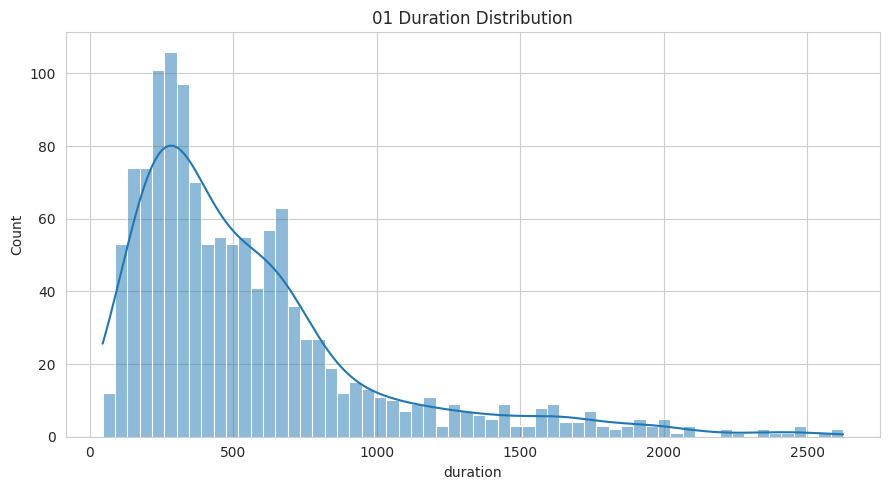

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(meta['duration'].dropna(), bins=60, kde=True)
plt.title('01 Duration Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_duration_distribution.png', dpi=160)
plt.show()


In [ ]:
import pretty_midi

# Keep only rows with valid duration range.
meta_processed = meta.dropna(subset=['midi_filename','duration']).copy()
meta_processed = meta_processed[(meta_processed['duration'] >= MIN_DURATION_SEC) & (meta_processed['duration'] <= MAX_DURATION_SEC)].reset_index(drop=True)


def extract_note_df(midi_path):
    """Return note timing table from one MIDI file."""
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    notes = []
    for inst in pm.instruments:
        notes.extend(inst.notes)
    if not notes:
        return pd.DataFrame(columns=['start','end','duration'])
    notes = sorted(notes, key=lambda n: n.start)
    s = np.array([n.start for n in notes], dtype=float)
    e = np.array([n.end for n in notes], dtype=float)
    return pd.DataFrame({'start': s, 'end': e, 'duration': np.maximum(e-s, 1e-6)})


def quantize_df(df, time_bin):
    """Quantize starts/ends onto fixed grid and compute ioi before/after."""
    out = df.copy()
    out['start_q'] = np.round(out['start'] / time_bin) * time_bin
    out['end_q'] = np.round(out['end'] / time_bin) * time_bin
    out['dur_q'] = np.maximum(out['end_q'] - out['start_q'], time_bin)
    out['ioi_raw'] = out['start'].diff().fillna(0.0)
    out['ioi_q'] = out['start_q'].diff().fillna(0.0)
    return out

sample = meta_processed.sample(min(QUANT_SAMPLE_FILES, len(meta_processed)), random_state=SEED)
qrows = []
for _, r in sample.iterrows():
    p = MIDI_BASE_DIR / str(r['midi_filename'])
    if not p.exists():
        continue
    try:
        ndf = extract_note_df(p)
        if len(ndf) == 0:
            continue
        qdf = quantize_df(ndf, TIME_BIN_SEC)
        qrows.append({
            'midi_filename': str(r['midi_filename']),
            'n_notes': len(qdf),
            'unique_ioi_raw': int(np.round(qdf['ioi_raw'], 4).nunique()),
            'unique_ioi_q': int(np.round(qdf['ioi_q'], 4).nunique()),
            'dur_std_raw': float(qdf['duration'].std()),
            'dur_std_q': float(qdf['dur_q'].std()),
        })
    except Exception:
        continue

quant_impact = pd.DataFrame(qrows)
quant_summary = pd.DataFrame([{
    'time_bin_sec': TIME_BIN_SEC,
    'mean_unique_ioi_raw': quant_impact['unique_ioi_raw'].mean() if len(quant_impact) else np.nan,
    'mean_unique_ioi_q': quant_impact['unique_ioi_q'].mean() if len(quant_impact) else np.nan,
    'mean_dur_std_raw': quant_impact['dur_std_raw'].mean() if len(quant_impact) else np.nan,
    'mean_dur_std_q': quant_impact['dur_std_q'].mean() if len(quant_impact) else np.nan,
}])

display(quant_summary)


,time_bin_sec,mean_unique_ioi_raw,mean_unique_ioi_q,mean_dur_std_raw,mean_dur_std_q
0,0.01,388.48,95.848,0.351728,0.351747


In [ ]:
# Save cache for downstream notebooks.
meta.to_csv(CACHE_DIR / 'meta_raw.csv', index=False)
meta_processed.to_csv(CACHE_DIR / 'meta_processed.csv', index=False)

pd.DataFrame([{
    'seed': SEED,
    'time_bin_sec': TIME_BIN_SEC,
    'min_duration_sec': MIN_DURATION_SEC,
    'max_duration_sec': MAX_DURATION_SEC,
}]).to_csv(CACHE_DIR / 'preprocess_config.csv', index=False)

# Save evidence tables/figures.
split_counts.to_csv(TABLE_DIR / '01_split_counts.csv', index=False)
split_ratios.to_csv(TABLE_DIR / '01_split_ratios.csv', index=False)
split_duration.to_csv(TABLE_DIR / '01_split_duration.csv', index=False)
missing_df.to_csv(TABLE_DIR / '01_missingness.csv', index=False)
quant_impact.to_csv(TABLE_DIR / '01_quantization_impact_per_file.csv', index=False)
quant_summary.to_csv(TABLE_DIR / '01_quantization_impact_summary.csv', index=False)

print('Saved notebook 01 outputs to', PROJECT_OUTPUT_DIR)


Saved notebook 01 outputs to /content/project_outputs


## Demo: Listen to MIDI Audio

This optional demo section lets you quickly audition a few dataset MIDI files in Colab.
It is non-disruptive and does not affect training/evaluation outputs.


In [ ]:
# Demo helper utilities (safe to run; falls back gracefully).
from pathlib import Path
import shutil
import tempfile
import numpy as np
import pandas as pd
from IPython.display import Audio, display

AUDIO_DEMO_DIR = (PROJECT_OUTPUT_DIR / 'cache' / 'audio_demo') if 'PROJECT_OUTPUT_DIR' in globals() else (CACHE_DIR / 'audio_demo')
AUDIO_DEMO_DIR.mkdir(parents=True, exist_ok=True)


def ensure_audio_demo_dir():
    AUDIO_DEMO_DIR.mkdir(parents=True, exist_ok=True)
    return AUDIO_DEMO_DIR


def render_midi_to_wav_or_array(midi_path: Path, wav_out_path: Path = None, sample_rate: int = 16000):
    """Try rendering in priority order: pretty_midi.fluidsynth -> midi2audio/fluidsynth CLI -> fallback none."""
    try:
        import pretty_midi
    except Exception as e:
        return {'ok': False, 'reason': f'pretty_midi unavailable: {e}'}

    # 1) Try pretty_midi.fluidsynth() to audio array.
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        audio = pm.fluidsynth(fs=sample_rate)
        if audio is not None and len(audio) > 0:
            return {'ok': True, 'mode': 'array', 'audio': audio, 'sr': sample_rate}
    except Exception:
        pass

    # 2) Try CLI fallback if available.
    fluidsynth_bin = shutil.which('fluidsynth')
    midi2audio_bin = shutil.which('midi2audio')
    if wav_out_path is None:
        wav_out_path = ensure_audio_demo_dir() / (midi_path.stem + '.wav')

    # Attempt `fluidsynth` directly if present (soundfont path unknown on many Colab runtimes).
    if fluidsynth_bin is not None:
        return {
            'ok': False,
            'reason': 'fluidsynth binary exists, but no guaranteed SoundFont path detected in this notebook. '
                      'Install/provide a .sf2 and call fluidsynth manually if needed.'
        }

    if midi2audio_bin is not None:
        return {
            'ok': False,
            'reason': 'midi2audio is installed but requires external SoundFont setup; configure manually if desired.'
        }

    # 3) Fallback
    return {
        'ok': False,
        'reason': 'No working synth backend found. You can still inspect selected MIDI filenames below.'
    }


def play_audio_array(audio_array, sample_rate: int = 16000):
    """Display playable audio widget from numpy array."""
    display(Audio(audio_array, rate=sample_rate, autoplay=False))


def play_midi_demo(midi_path: Path, title: str = '', sample_rate: int = 16000):
    """Render + play one MIDI, with safe fallback messaging."""
    print(f'--- {title} ---')
    print('MIDI:', midi_path)
    res = render_midi_to_wav_or_array(midi_path, sample_rate=sample_rate)
    if res.get('ok'):
        if res.get('mode') == 'array':
            play_audio_array(res['audio'], sample_rate=res['sr'])
        else:
            print('Rendered WAV:', res.get('wav_path'))
            display(Audio(filename=res['wav_path'], autoplay=False))
    else:
        print('Audio render skipped:', res.get('reason', 'Unknown reason'))


In [ ]:
# Demo sample: play 1-3 MIDI examples from processed metadata.
if 'meta_processed' not in globals():
    raise RuntimeError('meta_processed not found. Run preprocessing cells above first.')

ensure_audio_demo_dir()

demo_n = min(3, len(meta_processed))
demo_df = meta_processed.sample(demo_n, random_state=SEED)[['midi_filename', 'duration', 'split_norm']].reset_index(drop=True)
display(demo_df)

for i, row in demo_df.iterrows():
    midi_path = MIDI_BASE_DIR / str(row['midi_filename'])
    if not midi_path.exists():
        print(f'--- Demo {i+1} ---')
        print('Missing file:', midi_path)
        continue
    title = f"Demo {i+1} | split={row['split_norm']} | duration={row['duration']:.1f}s"
    play_midi_demo(midi_path, title=title, sample_rate=16000)

print('If no audio plays, this is expected on some Colab runtimes without a synth backend.')
print('You can still use the displayed MIDI paths/metadata for manual audition workflows.')


,midi_filename,duration,split_norm
0,2015/MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-f...,217.770833,train
1,2018/MIDI-Unprocessed_Recital8_MID--AUDIO_08_R...,1054.578272,val
2,2011/MIDI-Unprocessed_06_R3_2011_MID--AUDIO_R3...,487.864095,train


--- Demo 1 | split=train | duration=217.8s ---
MIDI: /content/maestro-v3.0.0/2015/MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_19_R1_2015_wav--4.midi
Audio render skipped: No working synth backend found. You can still inspect selected MIDI filenames below.
--- Demo 2 | split=val | duration=1054.6s ---
MIDI: /content/maestro-v3.0.0/2018/MIDI-Unprocessed_Recital8_MID--AUDIO_08_R1_2018_wav--2.midi
Audio render skipped: No working synth backend found. You can still inspect selected MIDI filenames below.
--- Demo 3 | split=train | duration=487.9s ---
MIDI: /content/maestro-v3.0.0/2011/MIDI-Unprocessed_06_R3_2011_MID--AUDIO_R3-D3_06_Track06_wav.midi
Audio render skipped: No working synth backend found. You can still inspect selected MIDI filenames below.
If no audio plays, this is expected on some Colab runtimes without a synth backend.
You can still use the displayed MIDI paths/metadata for manual audition workflows.


In [ ]:
import shutil
shutil.make_archive('project_outputs', 'zip', '/content/project_outputs')

'/content/project_outputs.zip'